In [111]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cpu'

In [112]:
data = pd.read_csv('./structuralparameters-vs-capacities.csv', index_col=False, header=0)
data

,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,0.015114,0.000241,1.596496,0.007,1.61,211,0.004
1,0.040332,0.000522,1.294051,0.007,1.70,361,0.005
2,0.051645,0.001990,3.851133,0.036,2.02,271,0.009
3,0.052998,0.001876,3.537582,0.014,1.86,232,0.004
4,0.053928,0.000946,1.752954,0.021,1.66,663,0.012
...,...,...,...,...,...,...,...
995,4.350774,0.015634,0.343634,0.675,13.05,4726,1.963
996,4.412086,0.015546,0.336735,0.663,11.24,4885,1.968
997,5.115723,0.015837,0.293674,0.707,8.13,5126,2.406
998,8.004842,0.016169,0.185792,0.790,10.77,5894,4.249


In [113]:
escaler_X = MinMaxScaler().fit(data.iloc[:, 0:2])
X = torch.from_numpy(np.array(escaler_X.transform(data.iloc[:, 0:2]))).type(torch.float32)
X, torch.max(X, dim=0), torch.min(X, dim=0), X.shape, type(X)

(tensor([[0.0000, 0.0000],
         [0.0030, 0.0151],
         [0.0043, 0.0942],
         ...,
         [0.6010, 0.8399],
         [0.9414, 0.8578],
         [1.0000, 0.8670]]),
 torch.return_types.max(
 values=tensor([1., 1.]),
 indices=tensor([999, 934])),
 torch.return_types.min(
 values=tensor([0., 0.]),
 indices=tensor([0, 0])),
 torch.Size([1000, 2]),
 torch.Tensor)

In [114]:
escaler_y = MinMaxScaler().fit(data.iloc[:, 2:])
y = torch.from_numpy(np.array(escaler_y.transform(data.iloc[:, 2:]))).type(torch.float32)
y, torch.max(y, dim=0), torch.min(y, dim=0), y.shape, type(y)

(tensor([[3.8655e-01, 0.0000e+00, 1.0381e-02, 1.6920e-03, 0.0000e+00],
         [3.0425e-01, 0.0000e+00, 1.8166e-02, 2.7073e-02, 2.1763e-04],
         [1.0000e+00, 3.6160e-02, 4.5848e-02, 1.1844e-02, 1.0881e-03],
         ...,
         [3.2066e-02, 8.7282e-01, 5.7439e-01, 8.3333e-01, 5.2274e-01],
         [2.7132e-03, 9.7631e-01, 8.0277e-01, 9.6328e-01, 9.2383e-01],
         [0.0000e+00, 1.0000e+00, 8.2266e-01, 9.4332e-01, 1.0000e+00]]),
 torch.return_types.max(
 values=tensor([1., 1., 1., 1., 1.]),
 indices=tensor([  2, 999, 995, 984, 999])),
 torch.return_types.min(
 values=tensor([0., 0., 0., 0., 0.]),
 indices=tensor([999,   0, 486, 149,   0])),
 torch.Size([1000, 5]),
 torch.Tensor)

In [115]:
idx_train, idx_test = train_test_split(np.arange(1000), test_size=1/3, random_state=42)

In [116]:
class dataset(Dataset):
  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
    self.X = X.to(device)
    self.y = y.to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [117]:
dataset_train = dataset(X[idx_train], y[idx_train])
dataset_test = dataset(X[idx_test], y[idx_test])

In [118]:
batch_size = 1

trainloader = DataLoader(dataset_train, batch_size=batch_size, 
                         shuffle=True)

train_acc_loader = DataLoader(dataset_train, batch_size=len(dataset_train))

testloader = DataLoader(dataset_test, batch_size=len(dataset_test))

In [119]:
class LinearRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        '''The network has 4 layers 
             - input layer
             - hidden layer
             - hidden layer
             - output layer
        '''
        super(LinearRegression, self).__init__()
        self.act = torch.nn.Sigmoid()
        self.input_to_hidden = nn.Linear(input_dim, hidden_dim)
        self.hidden_layer_1 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_layer_2 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_to_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden(x))
        x = self.act(self.hidden_layer_1(x))
        x = self.act(self.hidden_layer_2(x))
        x = self.hidden_to_output(x)
        return x

In [120]:
# number of features (len of X cols)
input_dim = X.shape[1]
# number of hidden layers
hidden_layers = 10
# output dimension is 1 because of linear regression
output_dim = y.shape[1]
# initiate the linear regression model
model = LinearRegression(input_dim, hidden_layers, output_dim).to(device)
print(model)

LinearRegression(
  (act): Sigmoid()
  (input_to_hidden): Linear(in_features=2, out_features=10, bias=True)
  (hidden_layer_1): Linear(in_features=10, out_features=10, bias=True)
  (hidden_layer_2): Linear(in_features=10, out_features=10, bias=True)
  (hidden_to_output): Linear(in_features=10, out_features=5, bias=True)
)


In [121]:
summary(model, input_size=(2,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]              30
           Sigmoid-2                   [-1, 10]               0
            Linear-3                   [-1, 10]             110
           Sigmoid-4                   [-1, 10]               0
            Linear-5                   [-1, 10]             110
           Sigmoid-6                   [-1, 10]               0
            Linear-7                    [-1, 5]              55
Total params: 305
Trainable params: 305
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [122]:
# criterion to computes the loss between input and target
criterion = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer = torch.optim.Adam(model.parameters())

In [123]:
trainingloss = []
testloss = []

In [124]:
model.eval()
X_acc_train, y_acc_train = next(iter(train_acc_loader))
X_acc_test, y_acc_test = next(iter(testloader))

In [125]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model.train()
    for (inputs, labels) in trainloader:
        # inputs, labels = data

        # forward propagation
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer.step()
    model.eval()
    # X_acc_train, y_acc_train = next(iter(train_acc_loader))
    trainingloss.append(criterion(model(X_acc_train), y_acc_train).item())
    # X_acc_test, y_acc_test = next(iter(testloader))
    testloss.append(criterion(model(X_acc_test), y_acc_test).item())  

100%|█████████████████████████████████████████| 100/100 [00:49<00:00,  2.01it/s]


In [130]:
import matplotlib
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 

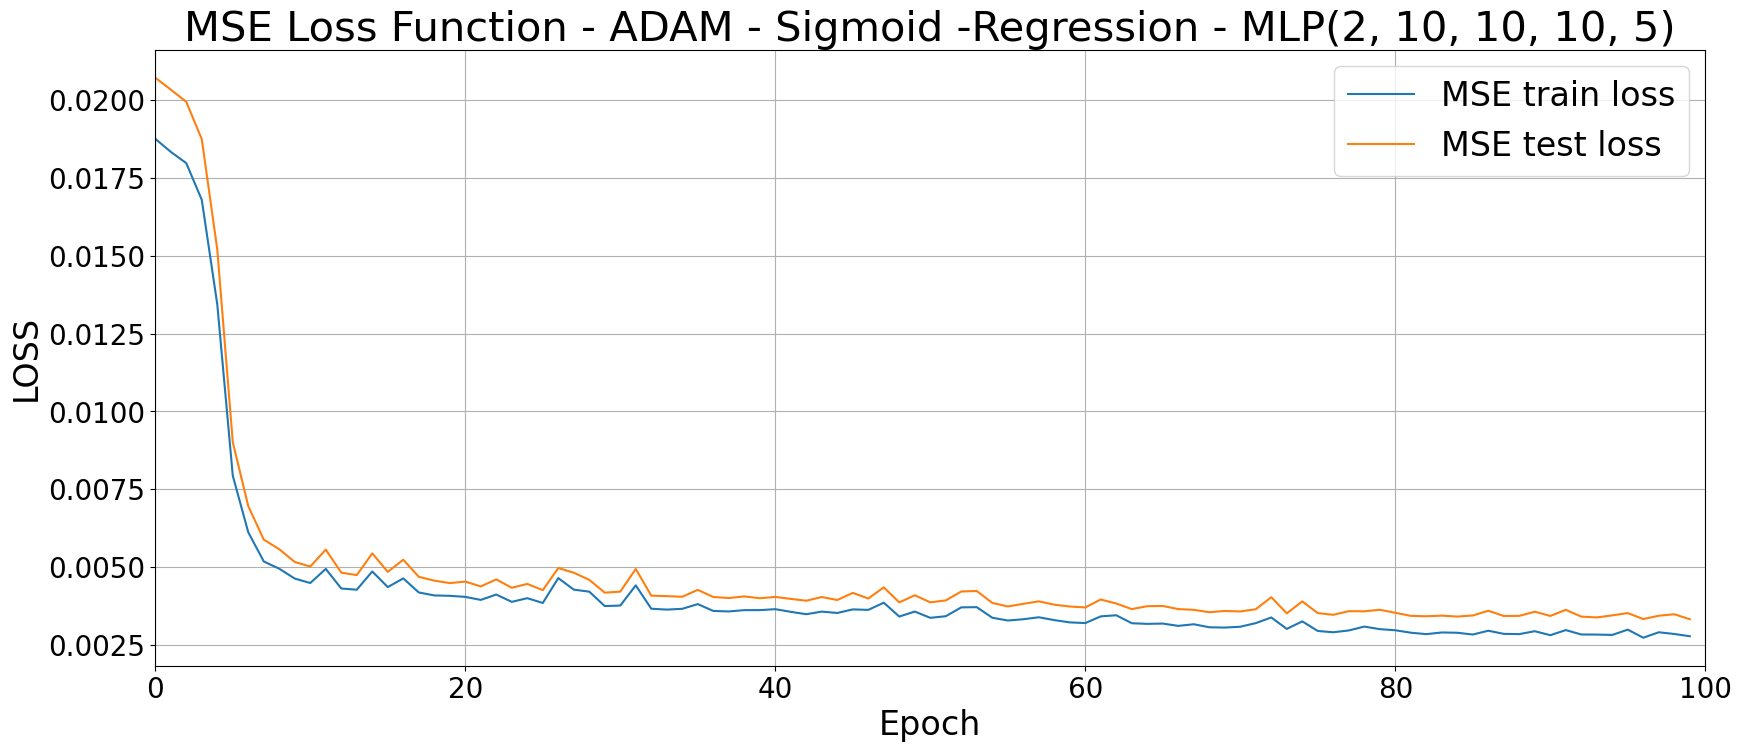

In [134]:
fig, ax = plt.subplots(figsize=(20,8))
ax.set_xlim(0, 100)
ax.plot(trainingloss, label='MSE train loss')
ax.plot(testloss, label='MSE test loss')
ax.set_xlabel('Epoch', fontsize=24)
ax.set_ylabel('LOSS', fontsize=24)
ax.legend(fontsize=24)
ax.grid()
ax.set_title("MSE Loss Function - ADAM - Sigmoid -Regression - MLP(2, 10, 10, 10, 5)", fontsize=30)

plt.show()

In [79]:
data_model = pd.DataFrame(columns=data.columns)

In [81]:
data_model.loc[0] = [2.75, 0.04, 0, 0, 0, 0, 0]

In [104]:
data_model.loc[1] = [5.5, 0.04, 0, 0, 0, 0, 0]

In [105]:
data_model

,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,2.75,0.04,0.597441,0.412711,5.685529,3561.799041,0.567314
1,5.50,0.04,0.000000,0.000000,0.000000,0.000000,0.000000


In [106]:
def salida_real(x_real):
    X_real_scaled = escaler_X.transform(x_real)
    return (model(torch.from_numpy(X_real_scaled).to(torch.float32)).detach().numpy() * escaler_y.data_range_) + escaler_y.data_min_

In [107]:
data_model.iloc[:, :2]

,usablegc,usablevc
0,2.75,0.04
1,5.50,0.04


In [108]:
data_model.iloc[:,2:]=salida_real(np.array(data_model.iloc[:, :2]))

/home/teodoro/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [109]:
data_model

,usablegc,usablevc,density,porosity,Ri,ssa,specific
0,2.75,0.04,0.597441,0.412711,5.685529,3561.799041,0.567314
1,5.50,0.04,0.385707,0.673122,8.369503,5165.876105,2.125020
